# valley-axis

Derives valley centerlines and computes continuous valley width across a valley floor mask.

Two centerline methods:
- **mcp**: Kienholz (2014) topographic cost-graph routing — uses DEM elevation and distance-to-wall penalty
- **skeleton**: morphological medial axis pruned to the stream network

Three width interpolation methods:
- **IDW**: inverse distance weighting from centerline pixels
- **Voronoi**: nearest centerline pixel allocation with Gaussian smoothing
- **Laplace**: harmonic interpolation solving ∇²W=0 with centerline as Dirichlet boundary and valley walls as Neumann boundary


In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import rioxarray as rxr

import valley_axis as va
from valley_axis.sample_data import get_sample_data

In [2]:
from matplotlib.colors import ListedColormap, BoundaryNorm
import numpy as np

def plot_region(ax, region):
    data = region.values.astype(float)
    data[data == region.rio.nodata] = np.nan
    cmap = ListedColormap(["#d4b896", "#a8c5a0"])  # tan=0, green=1
    norm = BoundaryNorm([0, 0.5, 1], cmap.N)
    ax.imshow(
        data,
        cmap=cmap,
        norm=norm,
        extent=[
            region.x.min(), region.x.max(),
            region.y.min(), region.y.max(),
        ],
        origin="upper",
    )

## Load sample data

In [3]:
data = get_sample_data()

dem = rxr.open_rasterio(data["dem"]).squeeze()
region = rxr.open_rasterio(data["region"]).squeeze()
flowlines = gpd.read_file(data["flowlines"])

print(f"DEM shape: {dem.shape}, CRS: {dem.rio.crs}")
print(f"Region shape: {region.shape}")
print(f"Flowlines: {len(flowlines)} features")

DEM shape: (2932, 1822), CRS: EPSG:3310
Region shape: (2932, 1822)
Flowlines: 760 features


## Full workflow

In [4]:
centerlines_gdf, centerlines_raster, widths = va.measure_width(
    dem=dem,
    region_raster=region,
    flowlines=flowlines,
    centerline_method="skeleton",
    width_method="laplace",
)

print(f"Centerline segments: {len(centerlines_gdf)}")
print(f"Centerlines raster — non-zero pixels: {(centerlines_raster.values > 0).sum()}")
print(f"Widths raster — valid pixels: {(widths.values > 0).sum()}")

Centerline segments: 711
Centerlines raster — non-zero pixels: 49726
Widths raster — valid pixels: 703779


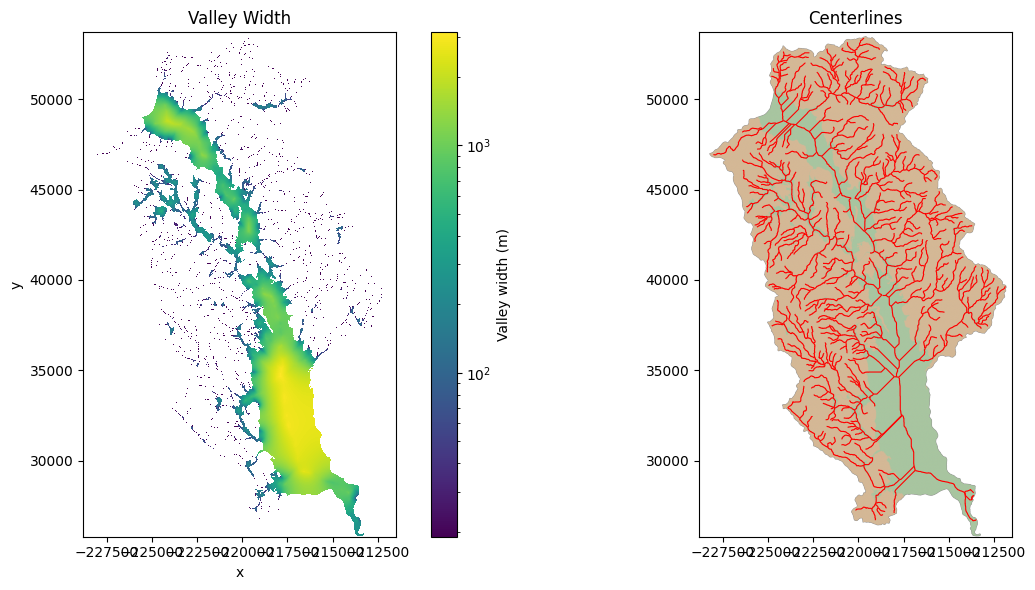

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

norm = LogNorm(vmin=widths.min(), vmax=widths.max())

widths.plot(ax=axes[0], cmap="viridis", norm=norm, cbar_kwargs={"label": "Valley width (m)"})
axes[0].set_title("Valley Width")
axes[0].set_aspect("equal")

plot_region(axes[1], region)
centerlines_gdf.plot(ax=axes[1], color="red", linewidth=0.8)
axes[1].set_title("Centerlines")
axes[1].set_aspect("equal")

plt.tight_layout()

## Centerlines

Compare two methods for deriving centerlines: glacial cost-based and medial axis

In [6]:
centerlines_mcp, _ = va.get_centerlines(dem, region, flowlines, method="mcp")
centerlines_skeleton, _ = va.get_centerlines(dem, region, flowlines, method="skeleton")

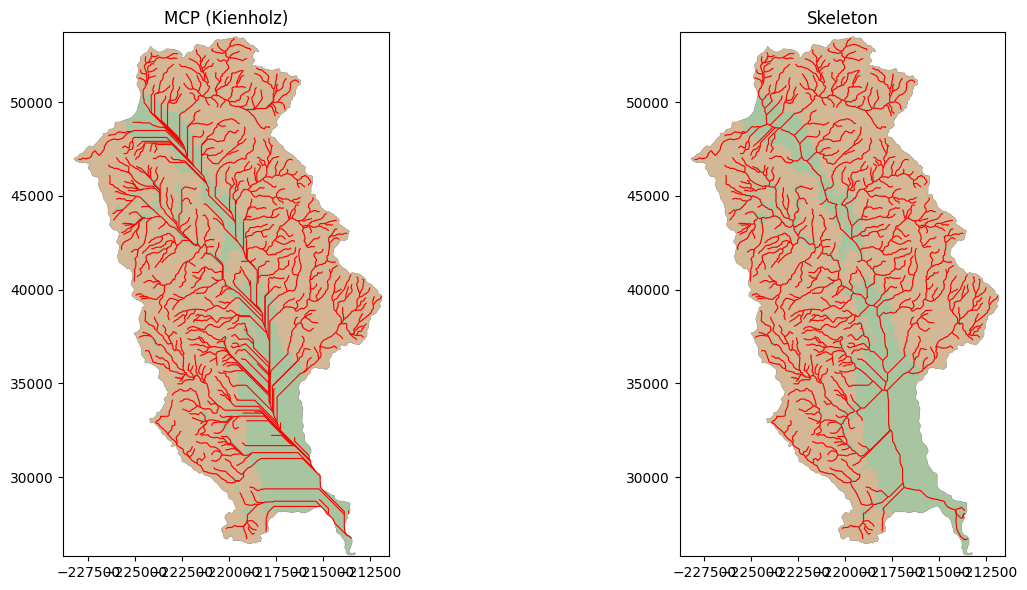

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, gdf, title in zip(
    axes,
    [centerlines_mcp, centerlines_skeleton],
    ["MCP (Kienholz)", "Skeleton"],
):
    plot_region(ax, region)
    gdf.plot(ax=ax, color="red", linewidth=0.8)
    ax.set_title(title)
    ax.set_aspect("equal")

plt.tight_layout()

## Width Interpolation

Compares methods for interpolating the width from the centerlines across the valley

In [33]:
widths_idw = va.get_widths(centerlines_raster, region, method="idw")
widths_voronoi = va.get_widths(centerlines_raster, region, method="voronoi")
widths_laplace = va.get_widths(centerlines_raster, region, method="laplace")
widths_hierarchical = va.get_widths(centerlines_raster, region, method="hierarchical", centerlines_gdf=centerlines_gdf)

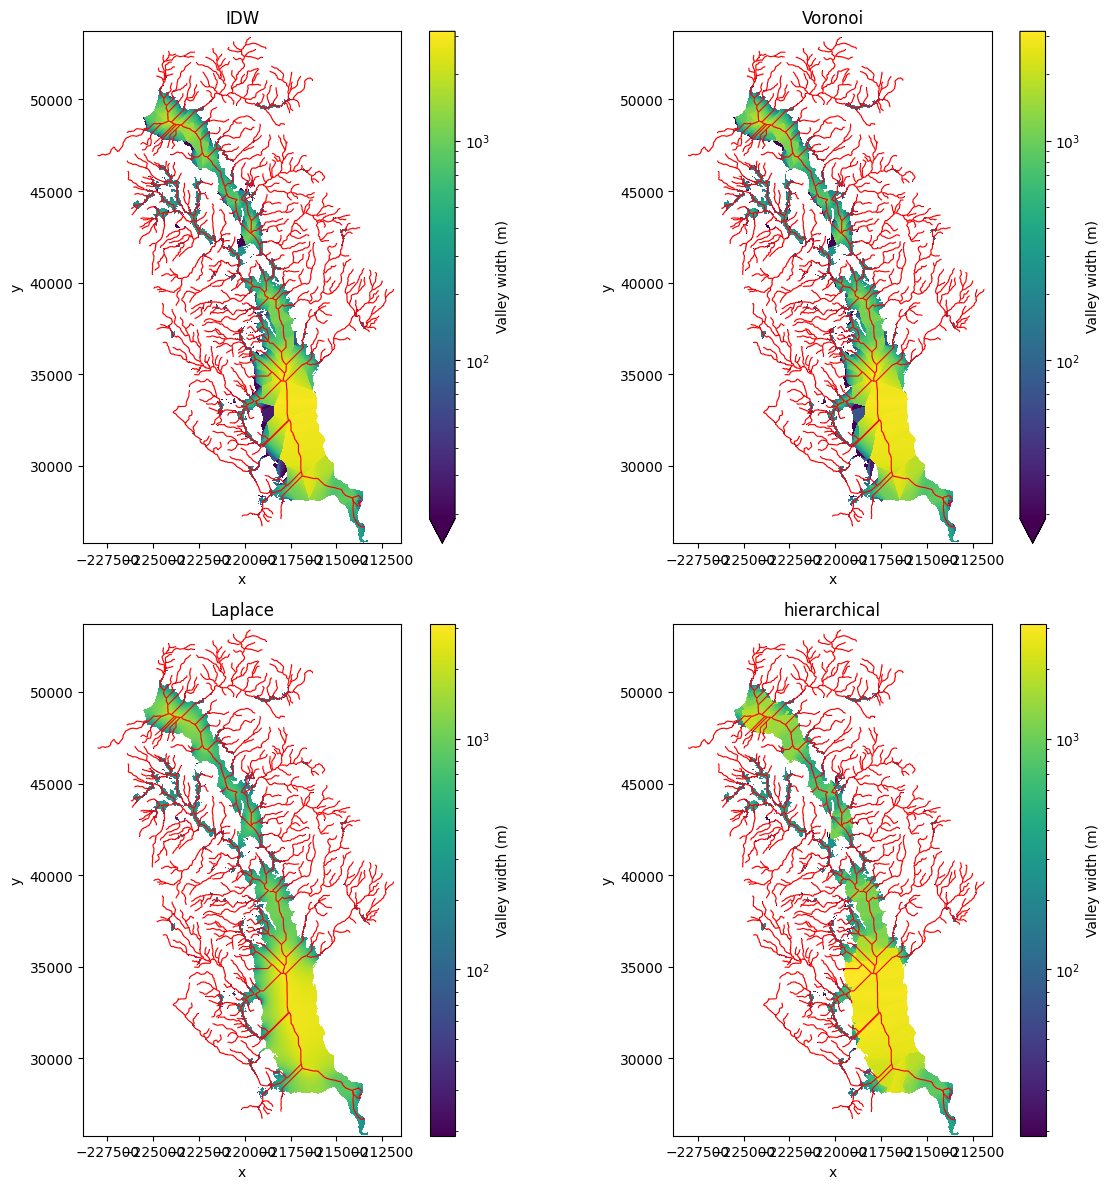

In [34]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

norm = LogNorm(vmin=widths_laplace.min(), vmax=widths_laplace.max())

for ax, w, title in zip(
    axes.flatten(),
    [widths_idw, widths_voronoi, widths_laplace, widths_hierarchical],
    ["IDW", "Voronoi", "Laplace", "hierarchical"],
):
    w.plot(ax=ax, cmap="viridis", norm=norm, cbar_kwargs={"label": "Valley width (m)"})
    centerlines_skeleton.plot(ax=ax, color="red", linewidth=0.8)
    ax.set_title(title)
    ax.set_aspect("equal")

plt.tight_layout()

In [35]:
widths_hierarchical.rio.to_raster('w2.tif')